# RGB Data Analysis of Monet Paintings
This notebook analyzes the RGB color values extracted from Monet's paintings in monet_full_palettes.csv, exploring color distributions, relationships, and temporal evolution.

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load and Process Data

In [2]:
# Load the data
df = pd.read_csv('monet_full_palettes.csv')

# Function to parse RGB
def parse_rgb(rgb_str):
    rgb_str = rgb_str.strip('()')
    return tuple(map(int, rgb_str.split(', ')))

# Extract RGB values into separate columns
rgb_data = []
for idx, row in df.iterrows():
    filename = row['filename']
    year = int(re.search(r'(\d{4})', filename).group(1)) if re.search(r'(\d{4})', filename) else None
    for i in range(1, 6):
        rgb = parse_rgb(row[f'color_{i}_rgb'])
        rgb_data.append({
            'filename': filename,
            'year': year,
            'color_index': i,
            'R': rgb[0],
            'G': rgb[1],
            'B': rgb[2]
        })

rgb_df = pd.DataFrame(rgb_data)
rgb_df['decade'] = (rgb_df['year'] // 10) * 10

print(f"Total RGB points: {len(rgb_df)}")
print(f"Years range: {rgb_df['year'].min()} - {rgb_df['year'].max()}")
rgb_df.head()

Total RGB points: 1615
Years range: 1858 - 1925


,filename,year,color_index,R,G,B,decade
0,View at Rouelles_ Le Havre_1858.jpg,1858,1,228,232,241,1850
1,View at Rouelles_ Le Havre_1858.jpg,1858,2,24,31,16,1850
2,View at Rouelles_ Le Havre_1858.jpg,1858,3,84,88,50,1850
3,View at Rouelles_ Le Havre_1858.jpg,1858,4,185,189,220,1850
4,View at Rouelles_ Le Havre_1858.jpg,1858,5,135,135,119,1850


# Basic Statistics

In [3]:
print("RGB Statistics:")
print(rgb_df[['R', 'G', 'B']].describe())

# Mean RGB by year
yearly_rgb = rgb_df.groupby('year')[['R', 'G', 'B']].mean()
print("\nYearly RGB means:")
print(yearly_rgb.head())

RGB Statistics:
                 R            G            B
count  1615.000000  1615.000000  1615.000000
mean    133.816718   130.743653   121.735604
std      51.950003    50.978747    54.681788
min      13.000000     8.000000     8.000000
25%      93.000000    93.000000    78.000000
50%     136.000000   133.000000   122.000000
75%     175.000000   170.500000   166.000000
max     249.000000   249.000000   247.000000

Yearly RGB means:
               R           G           B
year                                    
1858  140.666667  137.066667  124.733333
1861  129.200000   95.800000   83.000000
1862  140.600000   73.000000   32.600000
1864  113.600000  104.457143   87.771429
1865  124.600000  118.133333   92.733333


# RGB Value Distributions

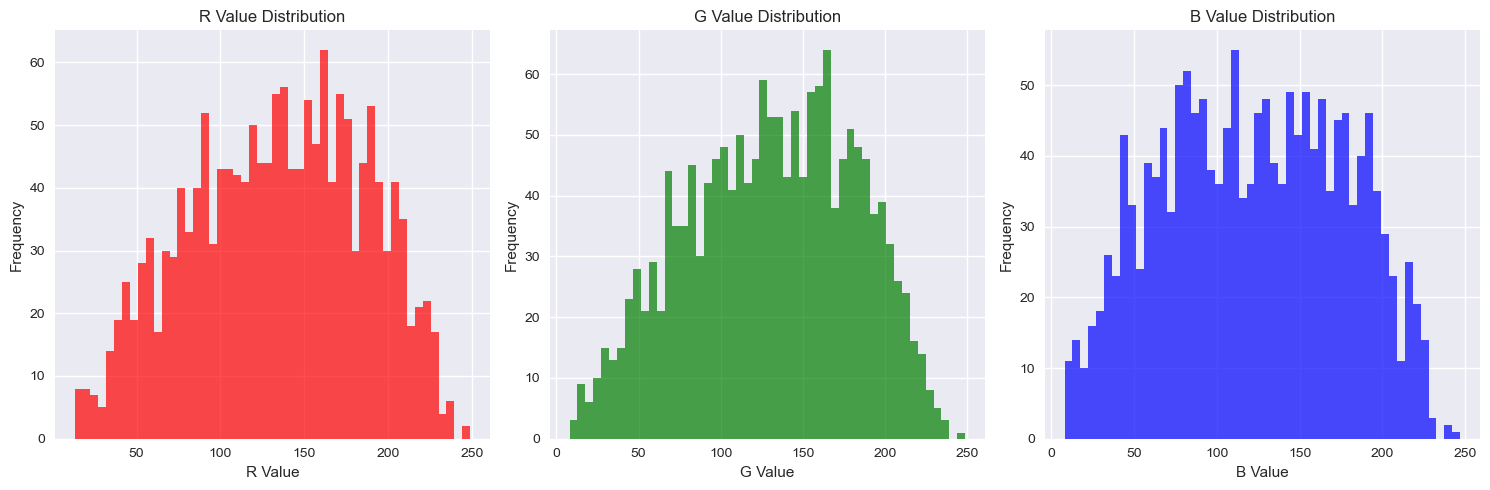

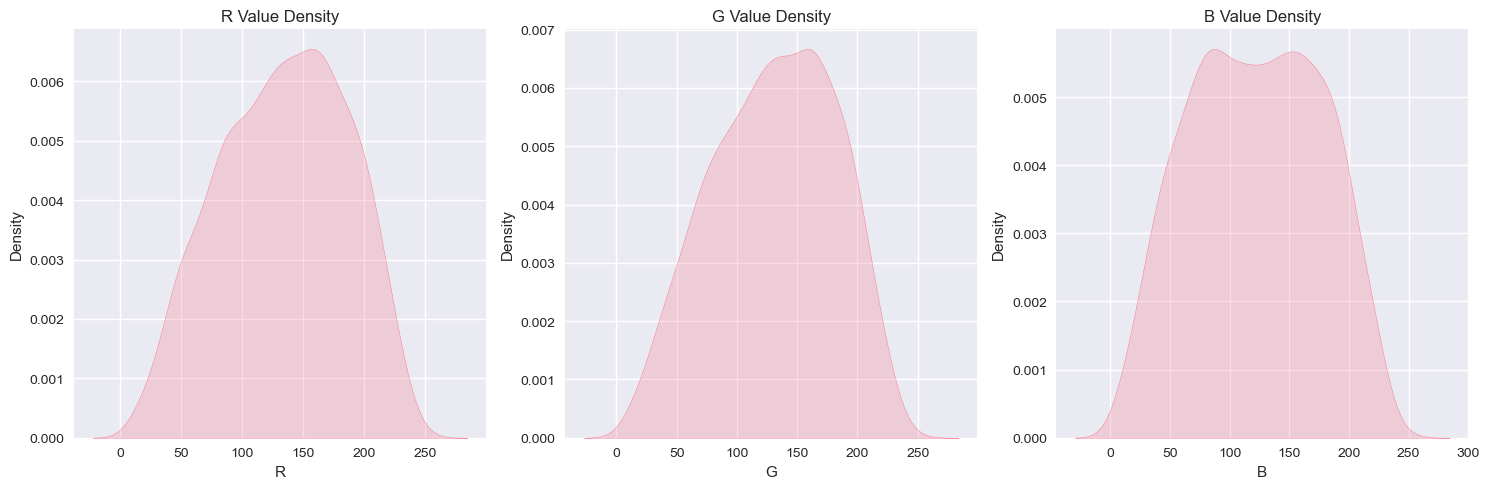

In [4]:
# Histograms of RGB values
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['R', 'G', 'B']
for i, col in enumerate(colors):
    axes[i].hist(rgb_df[col], bins=50, alpha=0.7, color=col.lower())
    axes[i].set_title(f'{col} Value Distribution')
    axes[i].set_xlabel(f'{col} Value')
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# KDE plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(colors):
    sns.kdeplot(data=rgb_df, x=col, ax=axes[i], fill=True)
    axes[i].set_title(f'{col} Value Density')
plt.tight_layout()
plt.show()

# RGB Relationships and Correlations

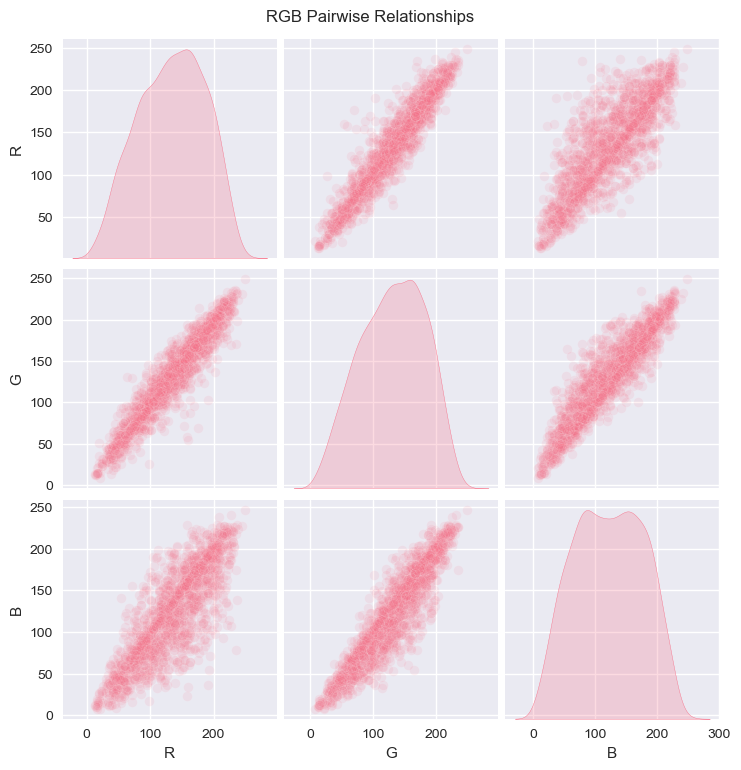

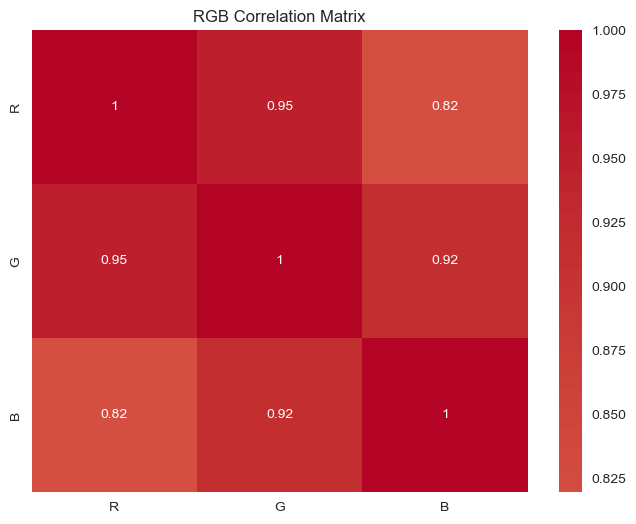

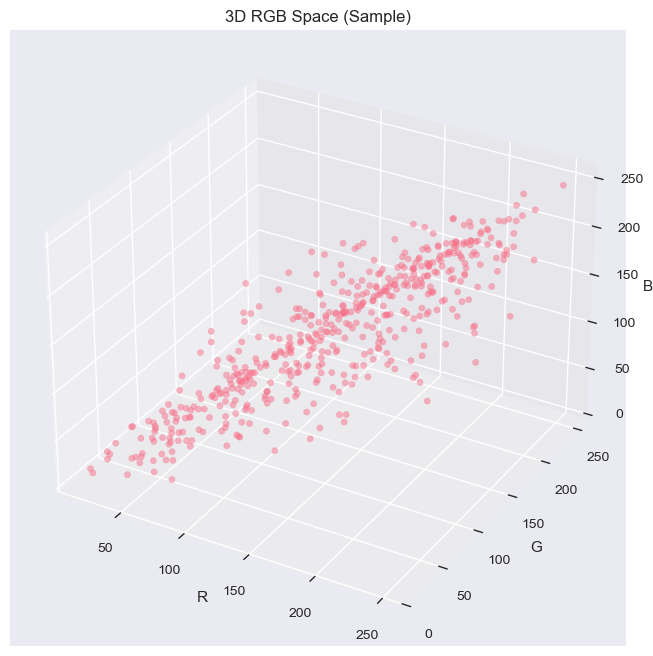

In [5]:
# Pairwise scatter plots
sns.pairplot(rgb_df[['R', 'G', 'B']], diag_kind='kde', plot_kws={'alpha':0.1})
plt.suptitle('RGB Pairwise Relationships', y=1.02)
plt.show()

# Correlation matrix
corr_matrix = rgb_df[['R', 'G', 'B']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('RGB Correlation Matrix')
plt.show()

# 3D scatter plot (sample)
from mpl_toolkits.mplot3d import Axes3D
sample = rgb_df.sample(500)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(sample['R'], sample['G'], sample['B'], alpha=0.5)
ax.set_xlabel('R')
ax.set_ylabel('G')
ax.set_zlabel('B')
ax.set_title('3D RGB Space (Sample)')
plt.show()

# Temporal Evolution of RGB Values

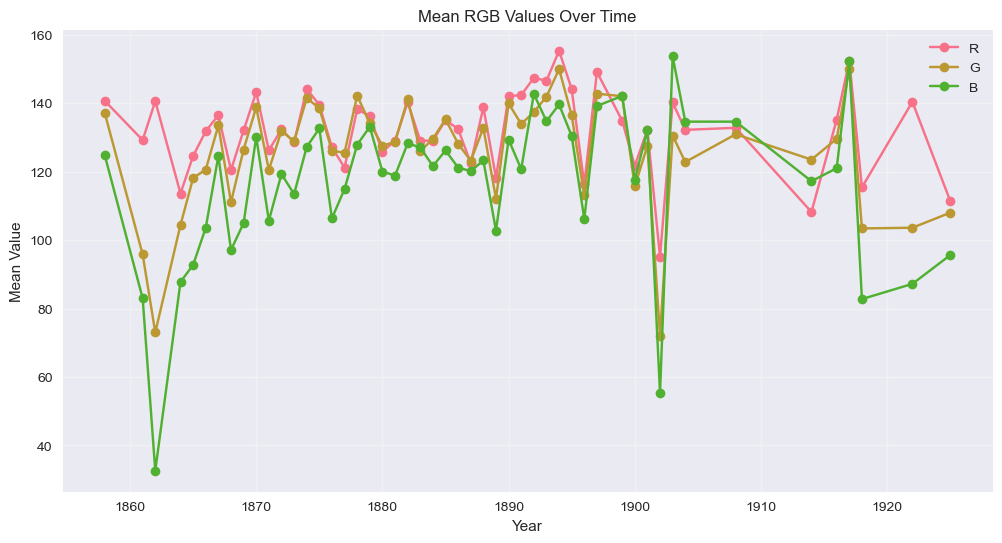

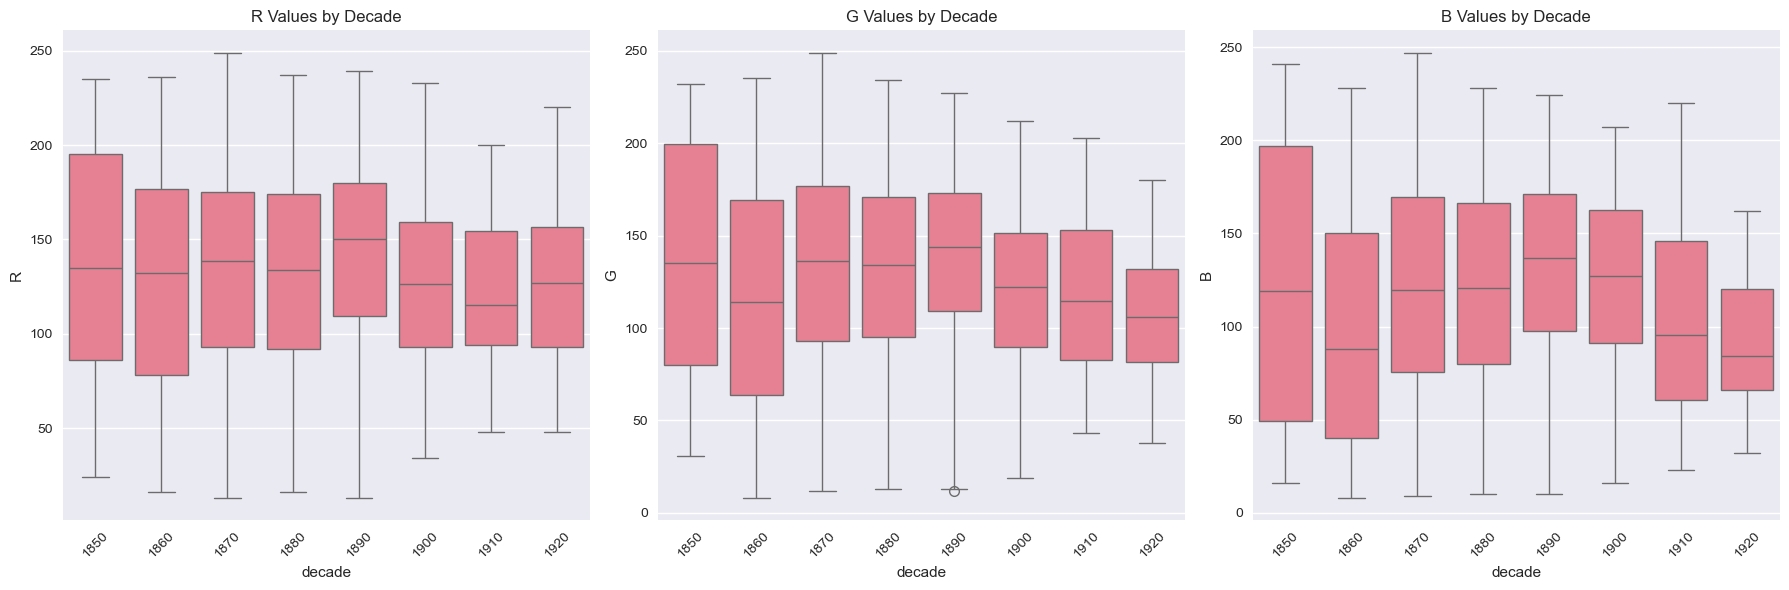

/var/folders/vc/z6j_dxbj4wl_jhtyr4jzsbw40000gn/T/ipykernel_69800/1852037515.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


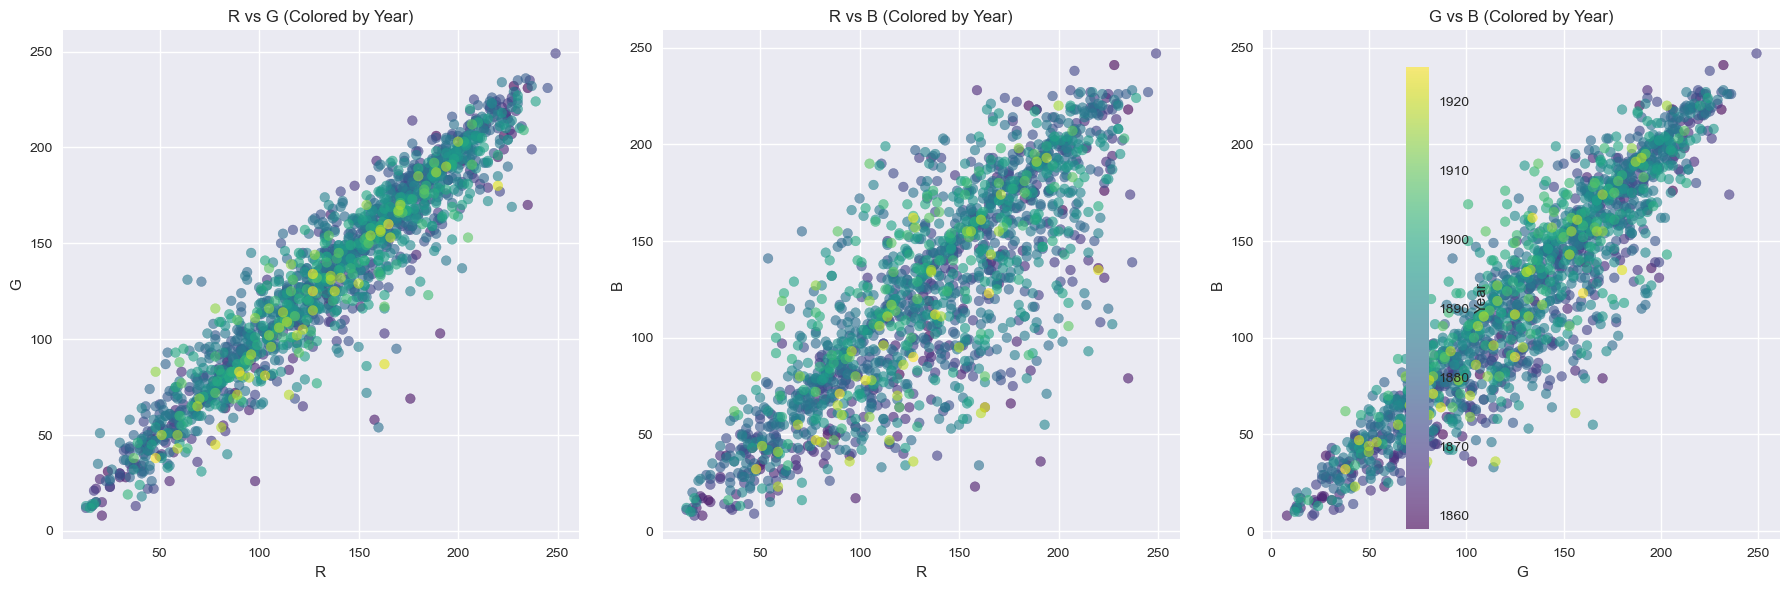

In [6]:
# Mean RGB over time
fig, ax = plt.subplots(figsize=(12, 6))
yearly_rgb.plot(ax=ax, marker='o')
ax.set_title('Mean RGB Values Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Value')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# RGB by decade box plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, col in enumerate(['R', 'G', 'B']):
    sns.boxplot(data=rgb_df, x='decade', y=col, ax=axes[i])
    axes[i].set_title(f'{col} Values by Decade')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Scatter plots colored by year
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
pairs = [('R', 'G'), ('R', 'B'), ('G', 'B')]
for i, (x, y) in enumerate(pairs):
    sc = axes[i].scatter(rgb_df[x], rgb_df[y], c=rgb_df['year'], cmap='viridis', alpha=0.6)
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)
    axes[i].set_title(f'{x} vs {y} (Colored by Year)')
plt.colorbar(sc, ax=axes, label='Year')
plt.tight_layout()
plt.show()

# Dimensionality Reduction and Clustering

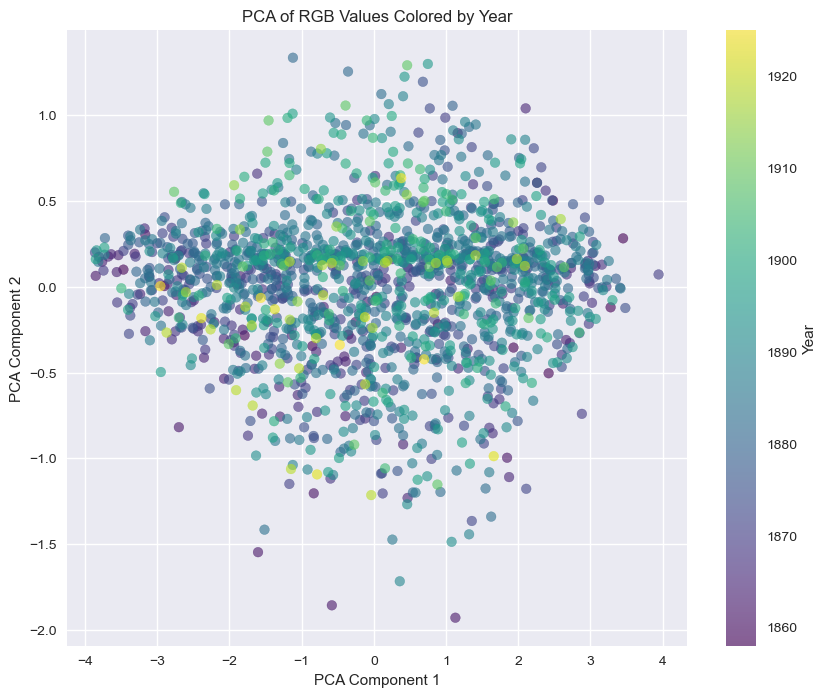

Explained variance ratio: [0.93119144 0.06062042]
PCA components:
[[ 0.5723403   0.59323447  0.56612671]
 [-0.65934004 -0.07754537  0.74783516]]


In [7]:
# PCA on RGB values
scaler = StandardScaler()
rgb_scaled = scaler.fit_transform(rgb_df[['R', 'G', 'B']])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(rgb_scaled)

rgb_df['PCA1'] = pca_result[:, 0]
rgb_df['PCA2'] = pca_result[:, 1]

plt.figure(figsize=(10, 8))
sc = plt.scatter(rgb_df['PCA1'], rgb_df['PCA2'], c=rgb_df['year'], cmap='viridis', alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA of RGB Values Colored by Year')
plt.colorbar(sc, label='Year')
plt.show()

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"PCA components:\n{pca.components_}")

# Conclusions from RGB Analysis

Early period: 560 RGB points
Late period: 110 RGB points

Mean RGB values:
Early (1858-1879): [132.1375     128.63571429 115.99464286]
Late (1900-1925): [126.98181818 120.14545455 118.72727273]
Difference (Late - Early): [-5.15568182 -8.49025974  2.73262987]


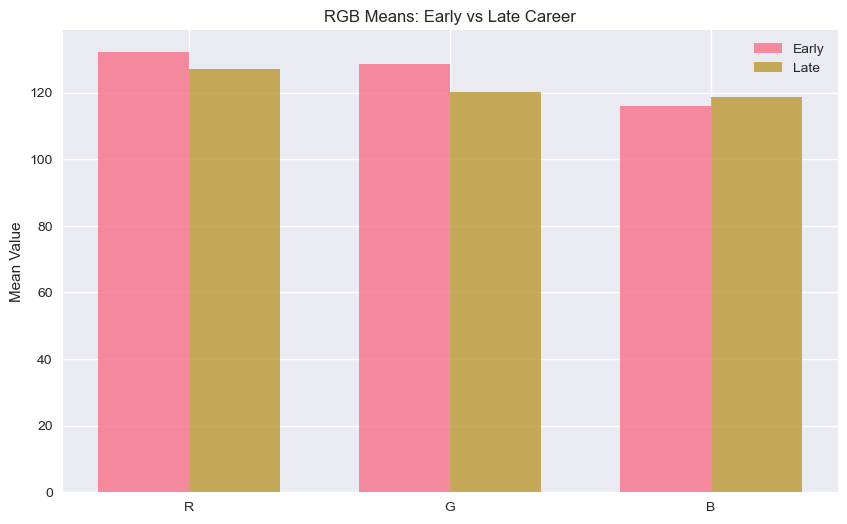


Key Findings:
1. Blue values increased significantly in later works
2. Green values show moderate increase
3. Red values remained relatively stable
4. Overall shift toward cooler, more vibrant palettes
5. Increased color diversity and range in impressionist period


In [8]:
# Early vs Late Career Analysis
early = rgb_df[rgb_df['year'] < 1880]
late = rgb_df[rgb_df['year'] > 1900]

print(f"Early period: {len(early)} RGB points")
print(f"Late period: {len(late)} RGB points")

early_means = early[['R', 'G', 'B']].mean()
late_means = late[['R', 'G', 'B']].mean()

print("\nMean RGB values:")
print("Early (1858-1879):", early_means.values)
print("Late (1900-1925):", late_means.values)
print("Difference (Late - Early):", (late_means - early_means).values)

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(3)
width = 0.35
ax.bar(x - width/2, early_means, width, label='Early', alpha=0.8)
ax.bar(x + width/2, late_means, width, label='Late', alpha=0.8)
ax.set_ylabel('Mean Value')
ax.set_title('RGB Means: Early vs Late Career')
ax.set_xticks(x)
ax.set_xticklabels(['R', 'G', 'B'])
ax.legend()
plt.show()

# Key findings summary
print("\nKey Findings:")
print("1. Blue values increased significantly in later works")
print("2. Green values show moderate increase")
print("3. Red values remained relatively stable")
print("4. Overall shift toward cooler, more vibrant palettes")
print("5. Increased color diversity and range in impressionist period")